# SynthACticBench O1: leaf policies across five SMAC seeds

Mean best-so-far trajectories with 95% confidence intervals and best-performance boxplots at every 100 trials.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/leaf_policies/02_leafs_seeds")
OUTPUT_DIRECTORY = HERE / "smac_output"
POLICIES = ("fixed_leaf_1", "fixed_leaf_2", "fixed_leaf_3", "staged_leaf_3_2_1")
SEEDS = tuple(range(5))
CHECKPOINTS = (100, 200, 300, 400, 500)
LABELS = {
    "fixed_leaf_1": "fixed leaf = 1",
    "fixed_leaf_2": "fixed leaf = 2",
    "fixed_leaf_3": "fixed leaf = 3",
    "staged_leaf_3_2_1": "staged 3 → 2 → 1",
}

In [2]:
def load_results(policy):
    by_seed = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        seed = result["smac_seed"]
        if seed in SEEDS and result["n_trials"] == 500:
            if seed not in by_seed or path.stat().st_mtime > by_seed[seed][0]:
                by_seed[seed] = (path.stat().st_mtime, result)
    missing = sorted(set(SEEDS) - set(by_seed))
    if missing:
        raise FileNotFoundError(f"Missing completed runs for {policy}, seeds={missing}")
    return {seed: by_seed[seed][1] for seed in SEEDS}


results = {policy: load_results(policy) for policy in POLICIES}
print(f"Loaded {sum(len(runs) for runs in results.values())}/20 trajectories.")

Loaded 20/20 trajectories.


In [3]:
# Verify that only the policy and SMAC seed vary.
comparison_fields = (
    "problem",
    "problem_seed",
    "instance_seed",
    "pythonhashseed",
    "n_instances",
    "instance_map",
    "n_trials",
)
reference = results["fixed_leaf_3"][0]
for policy, runs in results.items():
    for seed, result in runs.items():
        for field in comparison_fields:
            assert result[field] == reference[field], (policy, seed, field)
        assert result["smac_seed"] == seed

# For each seed, staged and fixed-leaf-3 must have an identical prefix.
for seed in SEEDS:
    staged = results["staged_leaf_3_2_1"][seed]
    fixed_three = results["fixed_leaf_3"][seed]
    assert staged["objective_value"][:150] == fixed_three["objective_value"][:150], seed

print("Settings match, and every staged run matches fixed leaf 3 for its first 150 trials.")
print("Staged transitions by seed:")
for seed in SEEDS:
    print(seed, results["staged_leaf_3_2_1"][seed]["transitions"])

Settings match, and every staged run matches fixed leaf 3 for its first 150 trials.
Staged transitions by seed:
0 [[0, 3], [150, 2], [302, 1]]
1 [[0, 3], [150, 2], [300, 1]]
2 [[0, 3], [156, 2], [307, 1]]
3 [[0, 3], [152, 2], [300, 1]]
4 [[0, 3], [150, 2], [300, 1]]


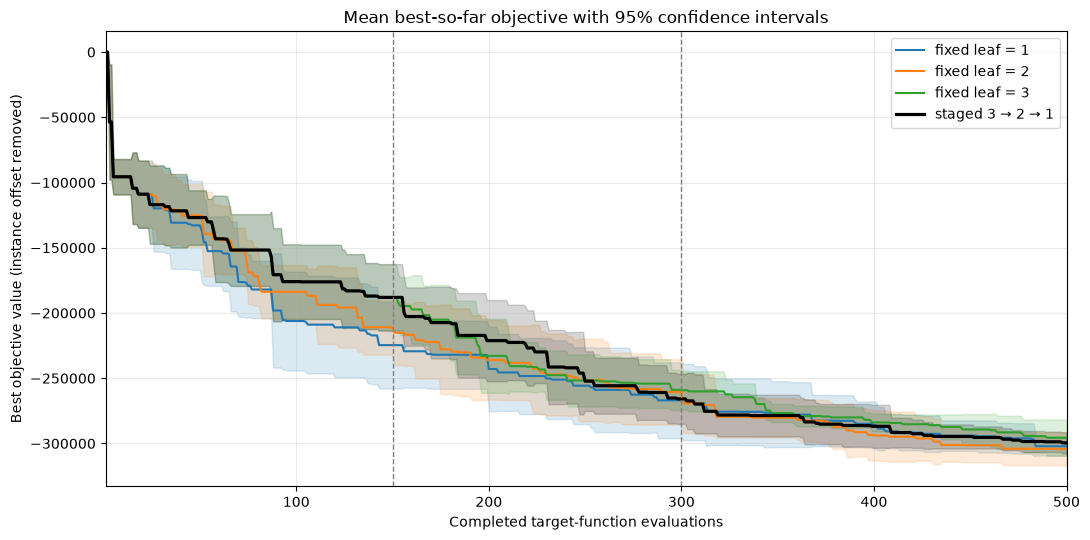

In [4]:
rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        rows.extend(
            {
                "policy": policy,
                "smac_seed": seed,
                "iteration": iteration,
                "best_so_far": best,
            }
            for iteration, best in zip(result["iteration"], result["best_so_far"])
        )
trajectories = pd.DataFrame(rows)
summary = (
    trajectories.groupby(["policy", "iteration"])["best_so_far"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(11, 5.5))
for policy in POLICIES:
    data = summary[summary["policy"] == policy]
    x = data["iteration"].to_numpy()
    mean = data["mean"].to_numpy()
    ci = data["ci95"].to_numpy()
    style = {"color": "black", "linewidth": 2.3} if policy == "staged_leaf_3_2_1" else {}
    line = ax.plot(x, mean, label=LABELS[policy], **style)[0]
    ax.fill_between(x, mean - ci, mean + ci, color=line.get_color(), alpha=0.16)

ax.axvline(150, color="grey", linestyle="--", linewidth=1)
ax.axvline(300, color="grey", linestyle="--", linewidth=1)
ax.set(
    title="Mean best-so-far objective with 95% confidence intervals",
    xlabel="Completed target-function evaluations",
    ylabel="Best objective value (instance offset removed)",
    xlim=(1, 500),
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

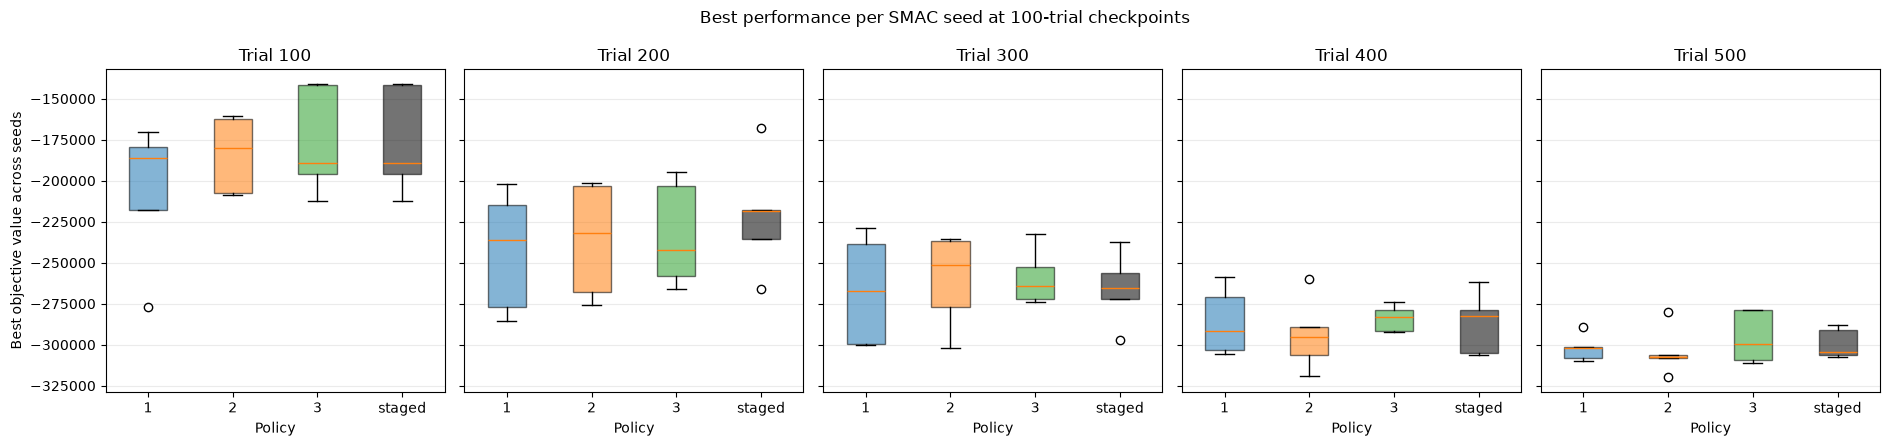

In [5]:
fig, axes = plt.subplots(1, len(CHECKPOINTS), figsize=(19, 4.5), sharey=True)
for ax, checkpoint in zip(axes, CHECKPOINTS):
    values = [
        [results[policy][seed]["best_so_far"][checkpoint - 1] for seed in SEEDS]
        for policy in POLICIES
    ]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=["1", "2", "3", "staged"])
    for box, color in zip(boxes["boxes"], ("C0", "C1", "C2", "black")):
        box.set(facecolor=color, alpha=0.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.set_xlabel("Policy")
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Best objective value across seeds")
fig.suptitle("Best performance per SMAC seed at 100-trial checkpoints")
plt.tight_layout()
plt.show()

In [6]:
checkpoint_table = (
    trajectories[trajectories["iteration"].isin(CHECKPOINTS)]
    .groupby(["iteration", "policy"])["best_so_far"]
    .agg(["mean", "std", "min", "median", "max"])
)
checkpoint_table

mean           std            min  \
iteration policy                                                          
100       fixed_leaf_1      -206141.743445  43314.536318 -276718.620949   
          fixed_leaf_2      -183754.187815  23406.704156 -208640.345844   
          fixed_leaf_3      -175973.007871  32675.682861 -212213.724449   
          staged_leaf_3_2_1 -175973.007871  32675.682861 -212213.724449   
200       fixed_leaf_1      -242937.907209  36973.443366 -285234.159408   
          fixed_leaf_2      -235963.116493  34815.347087 -275572.532656   
          fixed_leaf_3      -232867.923308  32312.725671 -266054.713354   
          staged_leaf_3_2_1 -221179.513031  35539.346736 -265868.017093   
300       fixed_leaf_1      -266923.643568  33203.461460 -299928.895530   
          fixed_leaf_2      -260493.803023  28582.625774 -301935.591066   
          fixed_leaf_3      -259169.174462  17104.796688 -274032.488539   
          staged_leaf_3_2_1 -265795.804155  21807.471001 -297069.897214   
400       fixed_leaf_1      -285908.474904  20614.557003 -305573.281773   
          fixed_leaf_2      -293896.840831  22092.176424 -318854.349864   
          fixed_leaf_3      -283917.552860   7851.482268 -292200.815190   
          staged_leaf_3_2_1 -286827.318782  18778.755916 -306253.185714   
500       fixed_leaf_1      -302155.245033   8171.393857 -310124.031962   
          fixed_leaf_2      -304266.757995  14659.682663 -319900.067744   
          fixed_leaf_3      -295616.800912  15861.290031 -311024.032393   
          staged_leaf_3_2_1 -299542.094215   9313.923657 -307763.715592   

                                    median            max  
iteration policy                                           
100       fixed_leaf_1      -185907.621103 -170503.471938  
          fixed_leaf_2      -180222.560233 -160327.374101  
          fixed_leaf_3      -189060.663660 -141031.125564  
          staged_leaf_3_2_1 -189060.663660 -141031.125564  
200       fixed_leaf_1      -236302.948849 -201778.207673  
          fixed_leaf_2      -231742.424786 -201380.402743  
          fixed_leaf_3      -242481.029236 -194390.624283  
          staged_leaf_3_2_1 -218459.413952 -168057.217410  
300       fixed_leaf_1      -267486.494474 -228729.335865  
          fixed_leaf_2      -251125.855160 -235663.172217  
          fixed_leaf_3      -264387.832309 -232555.583997  
          staged_leaf_3_2_1 -265707.588010 -237537.550872  
400       fixed_leaf_1      -291435.146769 -258577.211451  
          fixed_leaf_2      -295269.718645 -259974.457147  
          fixed_leaf_3      -283081.111417 -274219.925346  
          staged_leaf_3_2_1 -282418.281334 -261923.301041  
500       fixed_leaf_1      -301888.594565 -289163.333680  
          fixed_leaf_2      -307218.717866 -279996.941542  
          fixed_leaf_3      -299817.956638 -278691.028062  
          staged_leaf_3_2_1 -304533.536507 -288075.008694